### 1. Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momemtum, SGD with Nesterov,Adagrad, RMSProp,Adam)

In [ ]:
#Dataset path - /kaggle/input/datasets/eeshawn/flickr30k
#Images path - /kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images
#captions path - /kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images

#### XOR Dataset


===== Training Started =====

Training using Batch GD
Batch GD Final Accuracy: 0.7500
Batch GD Final Loss: 0.6187

Training using SGD
SGD Final Accuracy: 1.0000
SGD Final Loss: 0.1739

Training using SGD + Momentum
SGD + Momentum Final Accuracy: 1.0000
SGD + Momentum Final Loss: 0.0111

Training using RMSProp
RMSProp Final Accuracy: 1.0000
RMSProp Final Loss: 0.0000

Training using Adam
Adam Final Accuracy: 1.0000
Adam Final Loss: 0.0026

===== Final Optimizer Comparison =====
Optimizer            Accuracy        Loss           
Batch GD             0.7500          0.6187         
SGD                  1.0000          0.1739         
SGD + Momentum       1.0000          0.0111         
RMSProp              1.0000          0.0000         
Adam                 1.0000          0.0026         


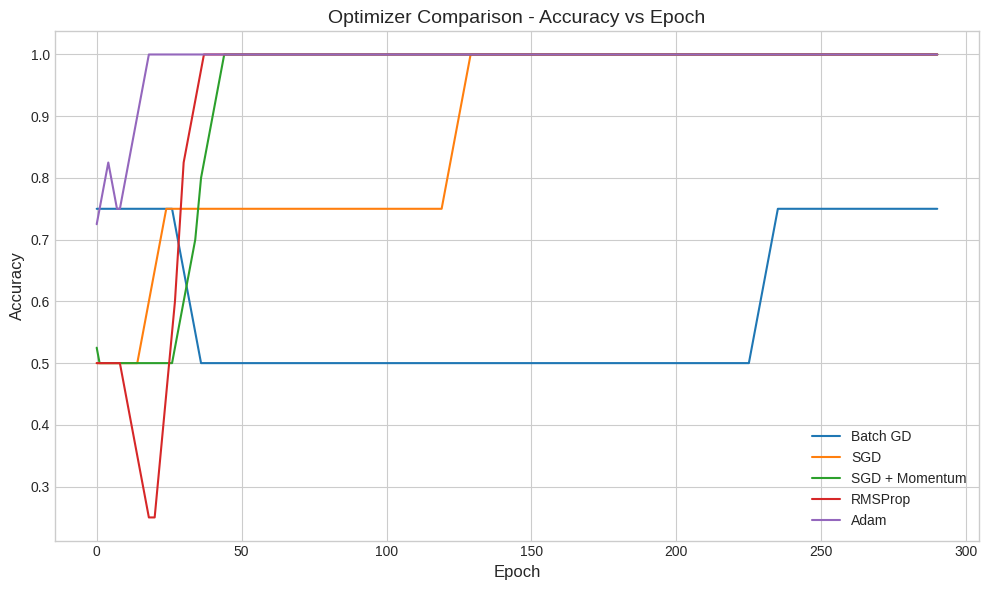

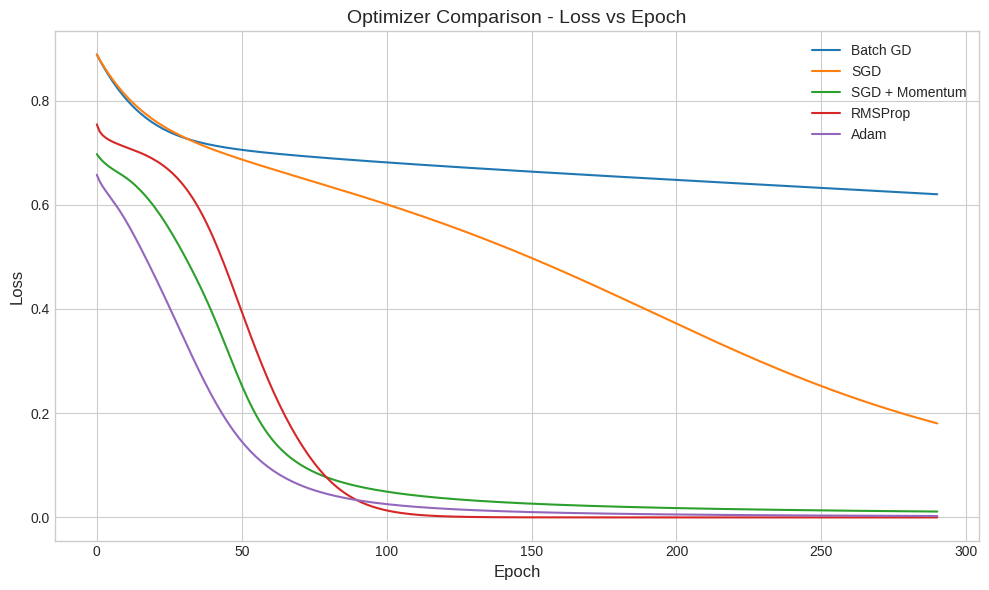

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress unnecessary TF logs

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# Fix randomness
tf.random.set_seed(42)
np.random.seed(42)

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = to_categorical([0,1,1,0])

# Model function (Fixed input warning)
def create_model(optimizer):
    model = Sequential([
        Input(shape=(2,)),
        Dense(8, activation='tanh'),
        Dense(4, activation='tanh'),
        Dense(2, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Important optimizers only
optimizers = {
    "Batch GD": (SGD(learning_rate=0.01), 4),
    "SGD": (SGD(learning_rate=0.01), 1),
    "SGD + Momentum": (SGD(learning_rate=0.01, momentum=0.9), 1),
    "RMSProp": (RMSprop(learning_rate=0.01), 1),
    "Adam": (Adam(learning_rate=0.01), 1)
}

histories = {}

print("\n===== Training Started =====")

for name, (optimizer, batch_size) in optimizers.items():
    
    print(f"\nTraining using {name}")
    
    model = create_model(optimizer)
    
    history = model.fit(
        X, y,
        epochs=300,
        batch_size=batch_size,
        verbose=0
    )
    
    histories[name] = history.history
    
    final_acc = history.history['accuracy'][-1]
    final_loss = history.history['loss'][-1]
    
    print(f"{name} Final Accuracy: {final_acc:.4f}")
    print(f"{name} Final Loss: {final_loss:.4f}")


print("\n===== Final Optimizer Comparison =====")
print("{:<20} {:<15} {:<15}".format("Optimizer", "Accuracy", "Loss"))

for name in histories:
    acc = histories[name]['accuracy'][-1]
    loss = histories[name]['loss'][-1]
    print("{:<20} {:<15.4f} {:<15.4f}".format(name, acc, loss))


# ---------------------------
# Professional Combined Graphs
# ---------------------------
plt.style.use('seaborn-v0_8-whitegrid')

# Accuracy Graph
plt.figure(figsize=(10,6))
for name in histories:
    acc = histories[name]['accuracy']
    smooth_acc = np.convolve(acc, np.ones(10)/10, mode='valid')
    plt.plot(smooth_acc, label=name)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Optimizer Comparison - Accuracy vs Epoch", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


# Loss Graph
plt.figure(figsize=(10,6))
for name in histories:
    loss = histories[name]['loss']
    smooth_loss = np.convolve(loss, np.ones(10)/10, mode='valid')
    plt.plot(smooth_loss, label=name)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Optimizer Comparison - Loss vs Epoch", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## Performance Characteristics of Different Gradient Descent Variants

### Batch Gradient Descent (BGD)
- Smooth convergence curve  
- Slower compared to other variants  
- Uses full dataset for each update  


### Stochastic Gradient Descent (SGD)
- Noisy updates  
- Fluctuating loss curve  
- Faster updates but unstable  


### Mini-Batch Gradient Descent
- Balanced noise and speed  
- More stable than SGD  
- Faster than Batch GD  


### SGD with Momentum
- Faster convergence  
- Reduces oscillations  
- Accumulates past gradients for smoother updates  



### SGD with Nesterov
- Slightly smoother than Momentum  
- Looks ahead before updating  
- More precise convergence  



### Adagrad
- Fast initial loss drop  
- Learning rate decreases over time  
- Slower in later stages  



### RMSProp
- Stable and smooth convergence  
- Controls learning rate decay  
- Performs well for non-stationary problems  


### Adam
- Fastest convergence  
- Smoothest learning curve  
- Combines Momentum and RMSProp advantages  


##### Batch Gradient Descent

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD

# XOR Dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = to_categorical([0,1,1,0])

# Model
model = Sequential([
    Dense(8, activation='relu', input_dim=2),
    Dense(4, activation='relu'),
    Dense(2, activation='softmax')
])

optimizer = SGD(learning_rate=0.1)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Batch GD → batch_size = full dataset
model.fit(X, y, epochs=500, batch_size=4, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print("Batch GD Accuracy:", acc)

2026-02-11 09:49:54.516767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770803394.710984      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770803394.764275      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770803395.210922      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770803395.210955      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770803395.210958      55 computation_placer.cc:177] computation placer alr

Batch GD Accuracy: 1.0


#### Stochastic Gradient Descent

In [10]:
optimizer = SGD(learning_rate=0.1)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# SGD → batch_size = 1
model.fit(X, y, epochs=500, batch_size=1, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print("SGD Accuracy:", acc)

SGD Accuracy: 1.0


#### Mini Batch Gradient Descent

In [3]:
optimizer = SGD(learning_rate=0.1)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Mini-batch → batch_size = 2
model.fit(X, y, epochs=500, batch_size=2, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print("Mini Batch GD Accuracy:", acc)

Mini Batch GD Accuracy: 1.0


#### Momentum Based Gradient Descent

In [4]:
optimizer = SGD(learning_rate=0.1, momentum=0.9)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=500, batch_size=1, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print("SGD + Momentum Accuracy:", acc)


SGD + Momentum Accuracy: 1.0


#### Nesterov Gradient Descent

In [5]:
optimizer = SGD(learning_rate=0.1, momentum=0.9, nesterov=True)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=500, batch_size=1, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print("SGD + Nesterov Accuracy:", acc)


SGD + Nesterov Accuracy: 1.0


#### Adagrad Gradient Descent

In [9]:
from tensorflow.keras.optimizers import Adagrad

optimizer = Adagrad(learning_rate=0.1)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=500, batch_size=1, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print("Adagrad Accuracy:", acc)

Adagrad Accuracy: 1.0


#### RMSProp

In [11]:
from tensorflow.keras.optimizers import RMSprop

optimizer = RMSprop(learning_rate=0.01)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=500, batch_size=1, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print("RMSProp Accuracy:", acc)

RMSProp Accuracy: 1.0


#### Custom Dataset (Customer Satisfaction)

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from tensorflow.keras.utils import to_categorical

# Load dataset (Kaggle path)
DATASET_PATH = "/kaggle/input/datasets/saijeevanbattiprolu/cs1234/Santander Customer Satisfaction_train.csv"
data = pd.read_csv(DATASET_PATH)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encoding
y = to_categorical(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MLP model
def create_mlp():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))
    return model

#### Batch Gradient Descent (BGD)

In [13]:
model = create_mlp()

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=len(X_train)   # FULL dataset
)

model.evaluate(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0486 - loss: 1.3211
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.0609 - loss: 1.2299
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.0792 - loss: 1.1473
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.1021 - loss: 1.0728
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.1297 - loss: 1.0056
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.1595 - loss: 0.9450
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.1935 - loss: 0.8905
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.2590 - loss: 0.8415
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.4233 - loss: 0.7974
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6119 - loss: 0.7578
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7279 - loss: 0.7222
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7808 - loss:

[0.4106576442718506, 0.9488292336463928]

#### Stochastic Gradient Descent (SGD)

In [15]:
model = create_mlp()

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=1   # ONE sample
)

model.evaluate(X_test, y_test)

Epoch 1/5
60816/60816 ━━━━━━━━━━━━━━━━━━━━ 110s 2ms/step - accuracy: 0.9581 - loss: 0.1591
Epoch 2/5
60816/60816 ━━━━━━━━━━━━━━━━━━━━ 108s 2ms/step - accuracy: 0.9599 - loss: 0.1419
Epoch 3/5
60816/60816 ━━━━━━━━━━━━━━━━━━━━ 109s 2ms/step - accuracy: 0.9604 - loss: 0.1389
Epoch 4/5
60816/60816 ━━━━━━━━━━━━━━━━━━━━ 109s 2ms/step - accuracy: 0.9616 - loss: 0.1851
Epoch 5/5
60816/60816 ━━━━━━━━━━━━━━━━━━━━ 109s 2ms/step - accuracy: 0.9608 - loss: 0.1347
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9610 - loss: 0.1387


[0.14453351497650146, 0.959550142288208]

#### Mini-Batch Gradient Descent

In [14]:
model = create_mlp()

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32
)

model.evaluate(X_test, y_test)

Epoch 1/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9415 - loss: 0.2202
Epoch 2/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9600 - loss: 0.1478
Epoch 3/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9610 - loss: 0.1421
Epoch 4/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9610 - loss: 0.1391
Epoch 5/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9616 - loss: 0.1375
Epoch 6/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9608 - loss: 0.1365
Epoch 7/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9607 - loss: 0.1355
Epoch 8/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9615 - loss: 0.1350
Epoch 9/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9617 - loss: 0.1338
Epoch 10/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9617 - loss: 0.1335
Epoch 11/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9611 - loss: 0.1332
Epoch 12/30
1901/1901 ━━━━━━━━

[0.14680783450603485, 0.959484338760376]

#### SGD with Momentum

In [18]:
model = create_mlp()

model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32
)

model.evaluate(X_test, y_test)

Epoch 1/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9468 - loss: 0.1692
Epoch 2/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9617 - loss: 0.1412
Epoch 3/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9618 - loss: 0.1383
Epoch 4/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9619 - loss: 0.1351
Epoch 5/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9619 - loss: 0.1339
Epoch 6/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9621 - loss: 0.1329
Epoch 7/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9620 - loss: 0.1319
Epoch 8/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9622 - loss: 0.1315
Epoch 9/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9623 - loss: 0.1306
Epoch 10/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9623 - loss: 0.1305
Epoch 11/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9623 - loss: 0.1299
Epoch 12/30
1901/1901 ━━━━━━━━

[0.1576368361711502, 0.9589581489562988]

#### SGD with Nesterov Momentum

In [19]:
model = create_mlp()

model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9,
        nesterov=True
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32
)

model.evaluate(X_test, y_test)

Epoch 1/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9607 - loss: 0.1586
Epoch 2/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9616 - loss: 0.1425
Epoch 3/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9618 - loss: 0.1360
Epoch 4/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9619 - loss: 0.1342
Epoch 5/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9620 - loss: 0.1332
Epoch 6/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9620 - loss: 0.1324
Epoch 7/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9622 - loss: 0.1314
Epoch 8/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9623 - loss: 0.1308
Epoch 9/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9622 - loss: 0.1303
Epoch 10/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9621 - loss: 0.1302
Epoch 11/30
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9626 - loss: 0.1290
Epoch 12/30
1901/1901 ━━━━━━━━

[0.1574987769126892, 0.9575769305229187]